In [1]:
import numpy as np
import pandas as pd
import random
from sklearn.linear_model import LogisticRegression
import sys

sys.path.insert(0, "../../../Modules")

pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)

from utils import *

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
NUTS0 = 'GR'
NUTS2 = 'Thessaly'

In [4]:
f = open(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_2010-2021_Cases_Dates.txt", "r")
print(f.read())

months: 7, 8, 9, 10, 
years: 2010, 2011, 2018, 2019, 2020, 


In [5]:
f = open(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_2022_Cases_Dates.txt", "r")
print(f.read())

months: 7, 8, 9, 10, 
years: 2022, 


In [6]:
r_u = 0.05
near_u = 0.25
smote = 1
scaler = 'minmax'
#years_to_remove = [year for year in range(2012, 2018)]
years_to_remove = []
path = f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_2010_2021.csv'
path2 = f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_2022.csv'

In [7]:
dataset = read_data(path, exclude_years = years_to_remove)
dataset.head()

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,22.75027,39.71097,2010-01-01,θεσσαλιας,αγιας,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,661.8,10705.0,17.3,45.76610,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.177143,14.644286,7.71,9.745684,4.044170,8.551413,3.117316,15.854022,4.895714,18.946151,6.782726,0.018327,0.018327,0.018327,8282.127022,1331.619869,1,123.585589,121.767859,183.036108,0.0,21.311709,22,76,20,76.0,20,76,9,9,4,2,2,2,0,8,0,0
1,22.69237,39.13639,2010-01-01,θεσσαλιας,αλμυρου,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,905.4,16004.0,20.6,45.23937,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.237778,17.085556,11.39,10.578306,4.632088,11.594181,4.298405,18.102979,6.260191,21.063313,8.144888,0.210382,0.210382,0.210382,10017.207897,1610.666116,14,259.585198,342.571837,171.163634,0.0,3.415750,21,78,20,78.0,20,78,8,8,4,1,1,2,0,1,0,0
2,24.07379,39.32896,2010-01-01,θεσσαλιας,αλοννησου,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,129.6,3153.0,21.2,46.11198,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.090000,17.810000,12.37,11.875455,10.167500,10.426667,8.035714,15.095333,9.928889,18.851600,10.540588,0.000000,0.000000,0.000000,1484.683259,55302.082778,24,302.637680,165.397106,195.027810,0.0,1.676994,21,93,20,93.0,20,93,8,8,4,1,1,2,0,1,0,0
3,21.43051,39.22138,2010-01-01,θεσσαλιας,αργιθεας,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,372.9,3515.0,9.3,44.69433,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.274889,0.318889,3.929167,-0.943095,11.973413,2.839991,16.749405,6.439643,49.209201,49.209201,49.209201,17128.150567,2537.700531,21,116.335477,1163.031269,147.596517,0.0,1.107140,11,93,10,95.0,10,95,1,1,7,1,1,2,0,10,0,0
4,22.88380,39.35198,2010-01-01,θεσσαλιας,βολου,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,385.6,138865.0,374.6,45.52194,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.383333,NaN,14.044643,4.790926,13.656768,4.280179,19.413810,6.542459,24.387230,8.781836,0.000000,0.000000,0.000000,5935.142744,3071.988689,5,143.181190,234.931813,174.426021,0.0,4.643743,31,95,30,95.0,30,95,10,10,1,6,6,2,0,13,0,0


In [8]:
#Check months

dataset = dataset.query('month >= 5 & month <= 10')
dataset.reset_index(inplace=True, drop=True)

In [9]:
dataset

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,22.75027,39.71097,2010-05-01,θεσσαλιας,αγιας,1,5,17,2010,0.201299,0.979530,0.500000,-0.866025,0.902798,-0.430065,661.8,10705.00,17.3,45.76610,0.609195,0.253011,-0.334019,-0.253011,0.582883,0.251005,-0.301984,-0.251005,0.073728,0.076980,0.048994,0.076980,17.568571,23.890000,11.247143,9.745684,4.044170,8.551413,3.117316,15.854022,4.895714,18.946151,6.782726,1.812624,38.206027,460.407901,8282.127022,1331.619869,1,123.585589,121.767859,183.036108,0.0,21.311709,22,76,20,76.0,20,76,9,9,4,2,2,2,0,8,16,0
1,22.69237,39.13639,2010-05-01,θεσσαλιας,αλμυρου,1,5,17,2010,0.201299,0.979530,0.500000,-0.866025,0.902798,-0.430065,905.4,16004.00,20.6,45.23937,0.532775,0.208840,-0.298796,-0.208840,0.516551,0.188381,-0.306085,-0.188381,0.043459,0.043465,0.032060,0.043465,18.926667,26.210000,11.643333,10.578306,4.632088,11.594181,4.298405,18.102979,6.260191,21.063313,8.144888,4.810882,20.903612,460.665028,10017.207897,1610.666116,14,259.585198,342.571837,171.163634,0.0,3.415750,21,78,20,78.0,20,78,8,8,4,1,1,2,0,1,2,0
2,24.07379,39.32896,2010-05-01,θεσσαλιας,αλοννησου,1,5,17,2010,0.201299,0.979530,0.500000,-0.866025,0.902798,-0.430065,129.6,3153.00,21.2,46.11198,0.468844,0.116777,-0.326605,-0.116777,0.471455,0.119810,-0.324888,-0.119810,0.025412,0.038572,0.028651,0.038572,16.870000,20.770000,12.970000,11.875455,10.167500,10.426667,8.035714,15.095333,9.928889,18.851600,10.540588,16.729268,33.335693,477.770927,1484.683259,55302.082778,24,302.637680,165.397106,195.027810,0.0,1.676994,21,93,20,93.0,20,93,8,8,4,1,1,2,0,1,2,0
3,21.43051,39.22138,2010-05-01,θεσσαλιας,αργιθεας,1,5,17,2010,0.201299,0.979530,0.500000,-0.866025,0.902798,-0.430065,372.9,3515.00,9.3,44.69433,0.515976,0.275715,-0.179673,-0.275715,0.485529,0.216562,-0.220690,-0.216562,0.043875,0.061608,0.052808,0.061608,16.393333,21.970000,10.816667,0.274889,0.318889,3.929167,-0.943095,11.973413,2.839991,16.749405,6.439643,0.349196,39.090641,641.408573,17128.150567,2537.700531,21,116.335477,1163.031269,147.596517,0.0,1.107140,11,93,10,95.0,10,95,1,1,7,1,1,2,0,10,20,0
4,22.88380,39.35198,2010-05-01,θεσσαλιας,βολου,1,5,17,2010,0.201299,0.979530,0.500000,-0.866025,0.902798,-0.430065,385.6,138865.00,374.6,45.52194,0.414560,0.132607,-0.253647,-0.132607,0.421641,0.115461,-0.288351,-0.115461,0.049906,0.061486,0.054518,0.061486,20.330000,28.363333,12.296667,14.044643,4.790926,13.656768,4.280179,19.413810,6.542459,24.387230,8.781836,5.515739,25.293264,440.108957,5935.142744,3071.988689,5,143.181190,234.931813,174.426021,0.0,4.643743,31,95,30,95.0,30,95,10,10,1,6,6,2,0,13,26,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3631,22.55316,39.85211,2021-10-16,θεσσαλιας,τεμπων,16,10,41,2021,-0.101168,-0.994869,-0.866025,0.500000,-0.989040,0.147647,576.7,11.99,23.8,45.79122,0.496181,0.108527,-0.447561,-0.108527,0.494762,0.101525,-0.448295,-0.101525,0.062635,0.074820,0.037224,0.074820,21.208000,26.462000,15.954000,5.517741,0.477349,10.868515,4.723090,12.528034,2.774820,19.173602,5.501974,182.178094,252.813196,1038.541043,15826.6006

In [10]:
dataset2 = read_data(path2, exclude_years = years_to_remove)
dataset2.head()

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,22.75027,39.71097,2022-01-01,θεσσαλιας,αγιας,1,1,52,2022,0.201299,0.97953,0.5,0.866025,-0.118273,0.992981,661.8,10705.0,17.3,45.76610,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.011429,12.470000,7.552857,5.780605,2.219699,9.428243,2.257183,10.448923,2.273378,21.082403,7.695856,0.000000,0.000000,0.000000,8282.127022,1331.619869,1,123.585589,121.767859,183.036108,0.0,21.311709,31,90,30,90.0,30,90,10,10,1,6,6,2,0,6,0,0
1,22.69237,39.13639,2022-01-01,θεσσαλιας,αλμυρου,1,1,52,2022,0.201299,0.97953,0.5,0.866025,-0.118273,0.992981,905.4,16004.0,20.6,45.23937,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.749306,12.377500,7.121111,8.616825,1.801932,11.624984,2.821047,13.074072,2.638302,22.638515,9.655879,0.000138,0.000138,0.000138,10017.207897,1610.666116,14,259.585198,342.571837,171.163634,0.0,3.415750,11,80,10,72.0,10,72,1,1,7,1,1,2,0,5,0,0
2,24.07379,39.32896,2022-01-01,θεσσαλιας,αλοννησου,1,1,52,2022,0.201299,0.97953,0.5,0.866025,-0.118273,0.992981,129.6,3153.0,21.2,46.11198,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.810000,10.958000,8.247143,12.676154,7.583333,12.528000,7.086364,19.002632,12.403333,0.453699,0.453699,0.453699,1484.683259,55302.082778,24,302.637680,165.397106,195.027810,0.0,1.676994,21,94,20,94.0,20,94,8,8,4,1,1,2,0,1,0,0
3,21.43051,39.22138,2022-01-01,θεσσαλιας,αργιθεας,1,1,52,2022,0.201299,0.97953,0.5,0.866025,-0.118273,0.992981,372.9,3515.0,9.3,44.69433,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.273333,10.310000,6.236667,3.110000,-0.850636,6.849744,0.523152,6.386697,-1.146587,18.678205,6.829016,0.455287,0.455287,0.455287,17128.150567,2537.700531,21,116.335477,1163.031269,147.596517,0.0,1.107140,11,97,10,99.0,10,99,1,1,7,1,1,2,0,12,0,0
4,22.88380,39.35198,2022-01-01,θεσσαλιας,βολου,1,1,52,2022,0.201299,0.97953,0.5,0.866025,-0.118273,0.992981,385.6,138865.0,374.6,45.52194,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.363333,7.776667,8.950000,10.279064,2.101397,13.378828,3.620000,14.613074,2.397455,24.653417,9.725712,0.000000,0.000000,0.000000,5935.142744,3071.988689,5,143.181190,234.931813,174.426021,0.0,4.643743,31,91,30,91.0,30,91,10,10,1,6,6,2,0,45,0,0


In [11]:
#Check months

dataset2 = dataset2.query('month >= 5 & month <= 10')
dataset2.reset_index(inplace=True, drop=True)

In [12]:
dataset2

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,22.75027,39.71097,2022-05-01,θεσσαλιας,αγιας,1,5,17,2022,0.201299,0.979530,0.500000,-8.660254e-01,0.902798,-0.430065,661.8,10705.00,17.3,45.76610,0.583182,0.201675,-0.506956,-0.201675,0.595923,0.216885,-0.509520,-0.216885,0.056127,0.063660,0.036076,0.063660,17.495714,24.630000,10.361429,5.780605,2.219699,9.428243,2.257183,10.448923,2.273378,21.082403,7.695856,1.437716,6.345927,553.075324,8282.127022,1331.619869,1,123.585589,121.767859,183.036108,0.0,21.311709,31,90,30,90.0,30,90,10,10,1,6,6,2,0,6,12,0
1,22.69237,39.13639,2022-05-01,θεσσαλιας,αλμυρου,1,5,17,2022,0.201299,0.979530,0.500000,-8.660254e-01,0.902798,-0.430065,905.4,16004.00,20.6,45.23937,0.598449,0.255150,-0.499790,-0.255150,0.586753,0.252751,-0.492671,-0.252751,0.049625,0.048529,0.029807,0.048529,18.151111,23.690000,12.612222,8.616825,1.801932,11.624984,2.821047,13.074072,2.638302,22.638515,9.655879,1.804692,4.536778,449.093673,10017.207897,1610.666116,14,259.585198,342.571837,171.163634,0.0,3.415750,11,80,10,72.0,10,72,1,1,7,1,1,2,0,5,10,0
2,24.07379,39.32896,2022-05-01,θεσσαλιας,αλοννησου,1,5,17,2022,0.201299,0.979530,0.500000,-8.660254e-01,0.902798,-0.430065,129.6,3153.00,21.2,46.11198,0.364064,0.147757,-0.313406,-0.147757,0.365731,0.143774,-0.311544,-0.143774,0.013259,0.035459,0.007434,0.035459,18.580000,22.410000,14.750000,10.958000,8.247143,12.676154,7.583333,12.528000,7.086364,19.002632,12.403333,1.581607,2.968344,664.307166,1484.683259,55302.082778,24,302.637680,165.397106,195.027810,0.0,1.676994,21,94,20,94.0,20,94,8,8,4,1,1,2,0,1,2,0
3,21.43051,39.22138,2022-05-01,θεσσαλιας,αργιθεας,1,5,17,2022,0.201299,0.979530,0.500000,-8.660254e-01,0.902798,-0.430065,372.9,3515.00,9.3,44.69433,0.581472,0.307244,-0.475062,-0.307244,0.538754,0.252306,-0.444476,-0.252306,0.045509,0.065142,0.026806,0.065142,18.766667,25.076667,12.456667,3.110000,-0.850636,6.849744,0.523152,6.386697,-1.146587,18.678205,6.829016,1.965355,2.747693,323.840951,17128.150567,2537.700531,21,116.335477,1163.031269,147.596517,0.0,1.107140,11,97,10,99.0,10,99,1,1,7,1,1,2,0,12,24,0
4,22.88380,39.35198,2022-05-01,θεσσαλιας,βολου,1,5,17,2022,0.201299,0.979530,0.500000,-8.660254e-01,0.902798,-0.430065,385.6,138865.00,374.6,45.52194,0.526887,0.173915,-0.462959,-0.173915,0.503354,0.163578,-0.442981,-0.163578,0.040866,0.043873,0.028314,0.043873,18.526667,27.423333,9.630000,10.279064,2.101397,13.378828,3.620000,14.613074,2.397455,24.653417,9.725712,2.900993,9.253188,489.461334,5935.142744,3071.988689,5,143.181190,234.931813,174.426021,0.0,4.643743,31,91,30,91.0,30,91,10,10,1,6,6,2,0,45,90,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
302,22.25731,39.56682,2022-09-01,θεσσαλιας,λαρισαιων,1,9,35,2022,0.201299,0.979530,-1.000000,-1.836970e-16,-0.845596,-0.533823,336.0,164381.00,483.9,45.39737,0.242602,-0.186117,-0.266601,0.186117,0.276567,-0.138791,-0.288544,0.138791,0.049921,0.061071,0.036903,0.061071,27.985000,35.770000,20.200000,10.551929,-1.222353,15.475000,0.971818,17.306667,0.820833,28.299333,9.236875,40.317953,178.76234

In [13]:
dataset['lau1'].unique().shape

(25,)

In [14]:
dataset2['lau1'].unique().shape

(25,)

In [15]:
dataset = pd.concat([dataset, dataset2], axis=0)

In [16]:
dataset.reset_index(drop=True, inplace=True)

In [17]:
dataset

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,22.75027,39.71097,2010-05-01,θεσσαλιας,αγιας,1,5,17,2010,0.201299,0.979530,0.500000,-8.660254e-01,0.902798,-0.430065,661.8,10705.00,17.3,45.76610,0.609195,0.253011,-0.334019,-0.253011,0.582883,0.251005,-0.301984,-0.251005,0.073728,0.076980,0.048994,0.076980,17.568571,23.890000,11.247143,9.745684,4.044170,8.551413,3.117316,15.854022,4.895714,18.946151,6.782726,1.812624,38.206027,460.407901,8282.127022,1331.619869,1,123.585589,121.767859,183.036108,0.0,21.311709,22,76,20,76.0,20,76,9,9,4,2,2,2,0,8,16,0
1,22.69237,39.13639,2010-05-01,θεσσαλιας,αλμυρου,1,5,17,2010,0.201299,0.979530,0.500000,-8.660254e-01,0.902798,-0.430065,905.4,16004.00,20.6,45.23937,0.532775,0.208840,-0.298796,-0.208840,0.516551,0.188381,-0.306085,-0.188381,0.043459,0.043465,0.032060,0.043465,18.926667,26.210000,11.643333,10.578306,4.632088,11.594181,4.298405,18.102979,6.260191,21.063313,8.144888,4.810882,20.903612,460.665028,10017.207897,1610.666116,14,259.585198,342.571837,171.163634,0.0,3.415750,21,78,20,78.0,20,78,8,8,4,1,1,2,0,1,2,0
2,24.07379,39.32896,2010-05-01,θεσσαλιας,αλοννησου,1,5,17,2010,0.201299,0.979530,0.500000,-8.660254e-01,0.902798,-0.430065,129.6,3153.00,21.2,46.11198,0.468844,0.116777,-0.326605,-0.116777,0.471455,0.119810,-0.324888,-0.119810,0.025412,0.038572,0.028651,0.038572,16.870000,20.770000,12.970000,11.875455,10.167500,10.426667,8.035714,15.095333,9.928889,18.851600,10.540588,16.729268,33.335693,477.770927,1484.683259,55302.082778,24,302.637680,165.397106,195.027810,0.0,1.676994,21,93,20,93.0,20,93,8,8,4,1,1,2,0,1,2,0
3,21.43051,39.22138,2010-05-01,θεσσαλιας,αργιθεας,1,5,17,2010,0.201299,0.979530,0.500000,-8.660254e-01,0.902798,-0.430065,372.9,3515.00,9.3,44.69433,0.515976,0.275715,-0.179673,-0.275715,0.485529,0.216562,-0.220690,-0.216562,0.043875,0.061608,0.052808,0.061608,16.393333,21.970000,10.816667,0.274889,0.318889,3.929167,-0.943095,11.973413,2.839991,16.749405,6.439643,0.349196,39.090641,641.408573,17128.150567,2537.700531,21,116.335477,1163.031269,147.596517,0.0,1.107140,11,93,10,95.0,10,95,1,1,7,1,1,2,0,10,20,0
4,22.88380,39.35198,2010-05-01,θεσσαλιας,βολου,1,5,17,2010,0.201299,0.979530,0.500000,-8.660254e-01,0.902798,-0.430065,385.6,138865.00,374.6,45.52194,0.414560,0.132607,-0.253647,-0.132607,0.421641,0.115461,-0.288351,-0.115461,0.049906,0.061486,0.054518,0.061486,20.330000,28.363333,12.296667,14.044643,4.790926,13.656768,4.280179,19.413810,6.542459,24.387230,8.781836,5.515739,25.293264,440.108957,5935.142744,3071.988689,5,143.181190,234.931813,174.426021,0.0,4.643743,31,95,30,95.0,30,95,10,10,1,6,6,2,0,13,26,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3938,22.25731,39.56682,2022-09-01,θεσσαλιας,λαρισαιων,1,9,35,2022,0.201299,0.979530,-1.000000,-1.836970e-16,-0.845596,-0.533823,336.0,164381.00,483.9,45.39737,0.242602,-0.186117,-0.266601,0.186117,0.276567,-0.138791,-0.288544,0.138791,0.049921,0.061071,0.036903,0.061071,27.985000,35.770000,20.200000,10.551929,-1.222353,15.475000,0.971818,17.306667,0.820833,28.299333,9.236875,40.317953,17

In [18]:
dsc = dataframe_describe(dataset)
dsc.head(15)

,year,non-case,case,total,percentage
0,2010,294,9,303,7.68%
1,2011,277,30,307,7.79%
2,2012,300,0,300,7.61%
3,2013,300,0,300,7.61%
4,2014,300,0,300,7.61%
5,2015,300,0,300,7.61%
6,2016,300,0,300,7.61%
7,2017,300,0,300,7.61%
8,2018,295,7,302,7.66%
9,2019,270,53,323,8.19%


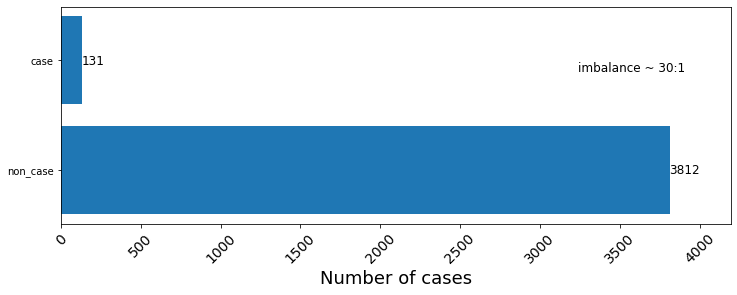

In [19]:
plot_imbalance(dataset)

In [20]:
path3 = f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_2023-May.csv'
data_test = read_data(path3, exclude_years = years_to_remove)
data_test.head()

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,22.75027,39.71097,2023-05-01,θεσσαλιας,αγιας,1,5,18,2023,0.201299,0.97953,0.5,-0.866025,0.845596,-0.533823,661.8,10705.0,17.3,45.76610,0.509207,0.119405,-0.451816,-0.119405,0.531592,0.254587,-0.428750,-0.254587,0.077768,0.058778,0.056475,0.058778,14.462857,19.015714,9.910000,10.014591,3.062158,9.497627,2.252233,16.518764,4.850248,17.420808,6.992874,2.381410,17.837466,76.675988,8282.127022,1331.619869,1,123.585589,121.767859,183.036108,0.0,21.311709,31,90,30,90.0,30,90,10,10,1,6,6,2,0,35,0,0
1,22.69237,39.13639,2023-05-01,θεσσαλιας,αλμυρου,1,5,18,2023,0.201299,0.97953,0.5,-0.866025,0.845596,-0.533823,905.4,16004.0,20.6,45.23937,0.645191,0.302370,-0.529492,-0.302370,0.618919,0.280067,-0.511682,-0.280067,0.056373,0.054701,0.034039,0.054701,15.187778,19.518889,10.856667,11.574271,4.271414,11.566611,3.165456,16.910796,6.859971,19.659042,8.292132,3.480882,69.269711,208.946587,10017.207897,1610.666116,14,259.585198,342.571837,171.163634,0.0,3.415750,11,80,10,72.0,10,72,1,1,7,1,1,2,0,6,0,0
2,24.07379,39.32896,2023-05-01,θεσσαλιας,αλοννησου,1,5,18,2023,0.201299,0.97953,0.5,-0.866025,0.845596,-0.533823,129.6,3153.0,21.2,46.11198,0.493058,0.137236,-0.431136,-0.137236,0.499103,0.137082,-0.425521,-0.137082,0.036059,0.052143,0.019232,0.052143,15.170000,17.510000,12.830000,12.912222,9.263333,11.806000,8.335714,15.332667,9.731333,17.710000,11.163333,7.946645,55.220344,163.677945,1484.683259,55302.082778,24,302.637680,165.397106,195.027810,0.0,1.676994,21,94,20,94.0,20,94,8,8,4,1,1,2,0,1,0,0
3,21.43051,39.22138,2023-05-01,θεσσαλιας,αργιθεας,1,5,18,2023,0.201299,0.97953,0.5,-0.866025,0.845596,-0.533823,372.9,3515.0,9.3,44.69433,0.597637,0.302454,-0.493106,-0.302454,0.560003,0.257320,-0.465701,-0.257320,0.040313,0.053018,0.024440,0.053018,11.640000,17.370000,5.910000,6.545931,2.202813,6.295806,-1.524472,12.140821,3.852222,13.211548,4.210667,8.412601,10.754827,141.474393,17128.150567,2537.700531,21,116.335477,1163.031269,147.596517,0.0,1.107140,11,97,10,99.0,10,99,1,1,7,1,1,2,0,105,0,0
4,22.88380,39.35198,2023-05-01,θεσσαλιας,βολου,1,5,18,2023,0.201299,0.97953,0.5,-0.866025,0.845596,-0.533823,385.6,138865.0,374.6,45.52194,0.510673,0.128033,-0.451844,-0.128033,0.513199,0.149993,-0.449576,-0.149993,0.048106,0.049815,0.032318,0.049815,18.563333,25.250000,11.876667,13.062496,4.339126,13.258730,3.548556,18.642628,6.426410,21.021667,8.192857,1.161971,49.566698,146.622452,5935.142744,3071.988689,5,143.181190,234.931813,174.426021,0.0,4.643743,31,91,30,91.0,30,91,10,10,1,6,6,2,0,30,0,0


In [21]:
coefficients = []
results_train = pd.DataFrame()
results_test = pd.DataFrame()
feature_names = dataset.select_dtypes(exclude=['object']).drop(columns = ['case']).columns

In [22]:
data_train = dataset
data_test = data_test
    
data_train.reset_index(inplace = True, drop = True)
data_test.reset_index(inplace = True, drop = True)
    
X_train = data_train.select_dtypes(exclude=['object']).drop(columns = ['case'])
y_train = data_train['case']
X_test = data_test.select_dtypes(exclude=['object']).drop(columns = ['case'])
y_test = data_test['case']
    
X_train, X_test, y_train, y_test, X_train_df = transform_data(X_train, X_test, y_train, y_test, r_u, near_u, smote, scaler_key=scaler)
    
w0,w1 = calculate_weights(y_train)

model = LogisticRegression(max_iter = 1000, class_weight = {0.0: w0, 1.0:w1}, n_jobs = -1, random_state = 0)
    
train, test, coef = train_and_predict(model, X_train_df, data_test, X_train, y_train, X_test, y_test)
    
results_train = results_train.append(train, ignore_index = True)
results_test = results_test.append(test, ignore_index = True)
coefficients.append(coef)
    
print(f"Year: {test['year'].iloc[0]} || w0:{w0}, w1:{w1} || ##")

Year: 2023 || w0:1, w1:11 || ##


In [24]:
results_test[results_test['day'] == 1].head(40)

,x,y,municipality,day,month,year,case,probability
2,22.55316,39.85211,τεμπων,1,5,2023,0,4.529044e-02
11,21.72537,39.29671,λιμνης πλαστηρα,1,5,2023,0,5.869576e-03
15,22.16727,39.98970,ελασσονας,1,5,2023,0,1.947827e-03
19,21.88992,39.23076,καρδιτσας,1,5,2023,0,1.007180e-03
21,21.48476,39.47540,πυλης,1,5,2023,0,7.174467e-04
22,21.95164,39.48269,παλαμα,1,5,2023,0,6.328988e-04
24,22.34300,39.82847,τυρναβου,1,5,2023,0,4.904772e-04
25,22.75027,39.71097,αγιας,1,5,2023,0,4.279156e-04
26,21.52379,39.74422,καλαμπακας,1,5,2023,0,3.932376e-04
28,21.43051,39.22138,αργιθεας,1,5,2023,0,3.307680e-04


In [25]:
results_test[results_test['day'] == 16].head(40)

,x,y,municipality,day,month,year,case,probability
0,22.55316,39.85211,τεμπων,16,5,2023,0,0.315697
1,22.16727,39.98970,ελασσονας,16,5,2023,0,0.052084
3,21.72537,39.29671,λιμνης πλαστηρα,16,5,2023,0,0.019771
4,21.95164,39.48269,παλαμα,16,5,2023,0,0.013543
5,21.48476,39.47540,πυλης,16,5,2023,0,0.012600
6,22.34300,39.82847,τυρναβου,16,5,2023,0,0.010481
7,22.25731,39.56682,λαρισαιων,16,5,2023,0,0.008206
8,21.52379,39.74422,καλαμπακας,16,5,2023,0,0.006534
9,21.88992,39.23076,καρδιτσας,16,5,2023,0,0.006332
10,21.43051,39.22138,αργιθεας,16,5,2023,0,0.006128
